In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# Cross sections

## 13 TeV

### beta=BR(LQ-->b tau)=0.5

In [4]:
# -------------------------
# cross sections
# -------------------------
xsec_file = '../DATA-wjets/signals/LQs-xsec-13TeV.txt'

xsec_data = np.loadtxt(xsec_file, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses = xsec_data[:,0].astype(int)

fidxsec_SLQ = dict(zip(masses, xsec_data[:,1]))
fidxsec_VLQ = dict(zip(masses, xsec_data[:,2]))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300]
0.04952818 [fb]
0.04338729 [fb]


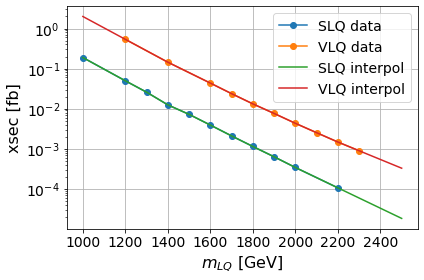

In [5]:
masses_SLQ = [1000, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
masses_VLQ = [1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]



fidxsec_SLQ_non0 = [fidxsec_SLQ[ii] for ii in masses_SLQ]
fidxsec_VLQ_non0 = [fidxsec_VLQ[ii] for ii in masses_VLQ]


#  interpolate
f_xsec_SLQ_log = interp1d(masses_SLQ, np.log10(fidxsec_SLQ_non0), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log = interp1d(masses_VLQ, np.log10(fidxsec_VLQ_non0), kind='linear', fill_value="extrapolate")

# evaluate
mass_its = np.linspace(1000,2500,100)
xsec_SLQ_its = 10**f_xsec_SLQ_log(mass_its)
xsec_VLQ_its = 10**f_xsec_VLQ_log(mass_its)



# plot
plt.plot(masses_SLQ, fidxsec_SLQ_non0, 'o-', label='SLQ data')
plt.plot(masses_VLQ, fidxsec_VLQ_non0, 'o-', label='VLQ data')

plt.plot(mass_its, xsec_SLQ_its, '-', label='SLQ interpol')
plt.plot(mass_its, xsec_VLQ_its, '-', label='VLQ interpol')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### different BR

In [7]:
# -------------------------
# cross sections
# -------------------------
xsec_file_betas = '../DATA-wjets/signals/LQs-xsec-13TeV-betas.txt'

xsec_data_betas = np.loadtxt(xsec_file_betas, comments='#')

# columns: 0=beta, 1=SLQ, 2=VLQ
betas = xsec_data_betas[:,0]

fidxsec_SLQ800 = dict(zip(betas, xsec_data_betas[:,1]))
fidxsec_SLQ1000 = dict(zip(betas, xsec_data_betas[:,2]))
fidxsec_SLQ1200 = dict(zip(betas, xsec_data_betas[:,3]))
fidxsec_SLQ1400 = dict(zip(betas, xsec_data_betas[:,4]))
fidxsec_SLQ1600 = dict(zip(betas, xsec_data_betas[:,5]))
fidxsec_SLQ1800 = dict(zip(betas, xsec_data_betas[:,6]))


print('betas: ', betas)
print(fidxsec_SLQ1200[1], '[fb]')

betas:  [0.  0.1 0.3 0.5 0.7 0.9 1. ]
0.03338212 [fb]


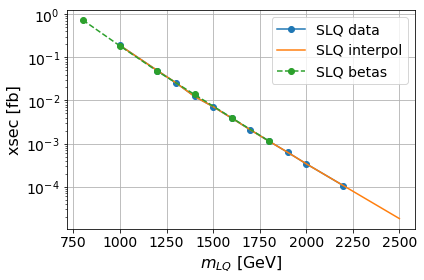

In [9]:
# CHECK

masses_SLQ_betas = [800, 1000, 1200, 1400, 1600, 1800]
fidxsec_SLQ_beta05 = [xsec_data_betas[3,ii+1] for ii in range(len(masses_SLQ_betas))]


# plot
plt.plot(masses_SLQ, fidxsec_SLQ_non0, 'o-', label='SLQ data')

plt.plot(mass_its, xsec_SLQ_its, '-', label='SLQ interpol')

plt.plot(masses_SLQ_betas, fidxsec_SLQ_beta05, 'o--', label='SLQ betas')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### betas ratio

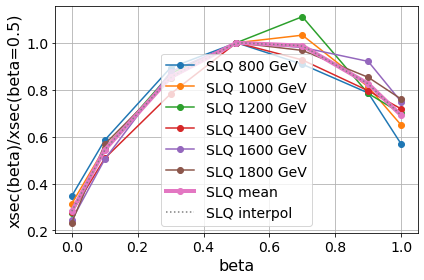

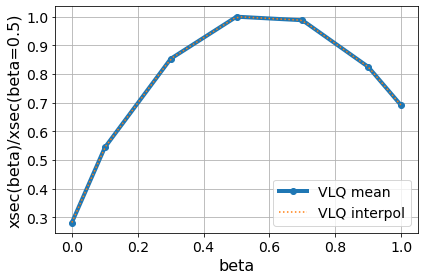

In [12]:
# SLQ
ratio_SLQ800 = np.array([fidxsec_SLQ800[b_it]/fidxsec_SLQ800[0.5] for b_it in betas ])
ratio_SLQ1000 = np.array([fidxsec_SLQ1000[b_it]/fidxsec_SLQ1000[0.5] for b_it in betas ])
ratio_SLQ1200 = np.array([fidxsec_SLQ1200[b_it]/fidxsec_SLQ1200[0.5] for b_it in betas ])
ratio_SLQ1400 = np.array([fidxsec_SLQ1400[b_it]/fidxsec_SLQ1400[0.5] for b_it in betas ])
ratio_SLQ1600 = np.array([fidxsec_SLQ1600[b_it]/fidxsec_SLQ1600[0.5] for b_it in betas ])
ratio_SLQ1800 = np.array([fidxsec_SLQ1800[b_it]/fidxsec_SLQ1800[0.5] for b_it in betas ])

ratio_SLQ_mean = np.mean(np.stack([ratio_SLQ800,ratio_SLQ1000,ratio_SLQ1200,ratio_SLQ1400,ratio_SLQ1600,ratio_SLQ1800], axis=1), axis=1)

#  interpolate
f_ratio_SLQ_log = interp1d(betas, ratio_SLQ_mean, kind='linear', fill_value="extrapolate")
# evaluate
beta_its = np.linspace(0,1,50)
beta_SLQ_its = f_ratio_SLQ_log(beta_its)


# plot
plt.plot(betas, ratio_SLQ800, 'o-', label='SLQ 800 GeV')
plt.plot(betas, ratio_SLQ1000, 'o-', label='SLQ 1000 GeV')
plt.plot(betas, ratio_SLQ1200, 'o-', label='SLQ 1200 GeV')
plt.plot(betas, ratio_SLQ1400, 'o-', label='SLQ 1400 GeV')
plt.plot(betas, ratio_SLQ1600, 'o-', label='SLQ 1600 GeV')
plt.plot(betas, ratio_SLQ1800, 'o-', label='SLQ 1800 GeV')

plt.plot(betas, ratio_SLQ_mean, 'o-', lw=4, label='SLQ mean')

plt.plot(beta_its, beta_SLQ_its, ':', label='SLQ interpol')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.yscale('log')
plt.xlabel("beta",fontsize=16)
plt.ylabel("xsec(beta)/xsec(beta=0.5)",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()




# VLQ

#  interpolate
f_ratio_VLQ_log = interp1d(betas, ratio_SLQ_mean, kind='linear', fill_value="extrapolate")
# evaluate
beta_VLQ_its = f_ratio_VLQ_log(beta_its)


# plot
plt.plot(betas, ratio_SLQ_mean, 'o-', lw=4, label='VLQ mean')

plt.plot(beta_its, beta_VLQ_its, ':', label='VLQ interpol')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.yscale('log')
plt.xlabel("beta",fontsize=16)
plt.ylabel("xsec(beta)/xsec(beta=0.5)",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### final function

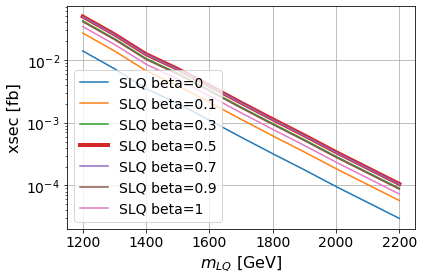

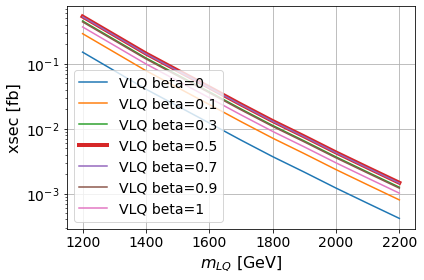

In [13]:
def fid_xsec_SLQ_13TeV(mass, beta):
    return 10**f_xsec_SLQ_log(mass) * f_ratio_SLQ_log(beta)

def fid_xsec_VLQ_13TeV(mass, beta):
    return 10**f_xsec_VLQ_log(mass) * f_ratio_VLQ_log(beta)


masses_X = np.linspace(1200,2200,100)


# plot SLQ
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0), '-', label='SLQ beta=0')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.1), '-', label='SLQ beta=0.1')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.3), '-', label='SLQ beta=0.3')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.5), '-', lw=4, label='SLQ beta=0.5')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.7), '-', label='SLQ beta=0.7')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.9), '-', label='SLQ beta=0.9')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,1), '-', label='SLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot VLQ
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0), '-', label='VLQ beta=0')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.1), '-', label='VLQ beta=0.1')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.3), '-', label='VLQ beta=0.3')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.5), '-', lw=4, label='VLQ beta=0.5')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.7), '-', label='VLQ beta=0.7')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.9), '-', label='VLQ beta=0.9')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,1), '-', label='VLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

## 14 TeV

### beta=BR(LQ-->b tau)=0.5

In [14]:
# -------------------------
# cross sections
# -------------------------
xsec_file_14TeV = '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)

fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]))


print('masses: ', masses_14TeV)
print(fidxsec_SLQ_14TeV[1200], '[fb]')
print(fidxsec_VLQ_14TeV[1600], '[fb]')

masses:  [1000 1200 1400 1600 1800 2000 2200]
0.1310740352079 [fb]
0.14050164 [fb]


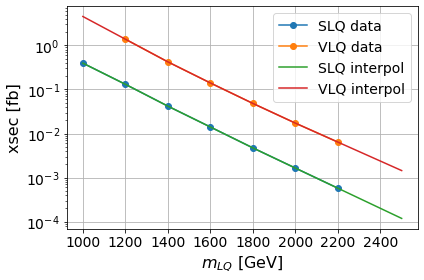

In [15]:
masses_SLQ_14TeV = [1000, 1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]



fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")

# evaluate
mass_its_14TeV = np.linspace(1000,2500,100)
xsec_SLQ_its_14TeV = 10**f_xsec_SLQ_log_14TeV(mass_its_14TeV)
xsec_VLQ_its_14TeV = 10**f_xsec_VLQ_log_14TeV(mass_its_14TeV)



# plot
plt.plot(masses_SLQ_14TeV, fidxsec_SLQ_non0_14TeV, 'o-', label='SLQ data')
plt.plot(masses_VLQ_14TeV, fidxsec_VLQ_non0_14TeV, 'o-', label='VLQ data')

plt.plot(mass_its_14TeV, xsec_SLQ_its_14TeV, '-', label='SLQ interpol')
plt.plot(mass_its_14TeV, xsec_VLQ_its_14TeV, '-', label='VLQ interpol')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### different BR

In [16]:
# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1=SLQ, 2=VLQ
betas = xsec_data_betas_14TeV[:,0]

fidxsec_SLQ1200_14TeV = dict(zip(betas, xsec_data_betas_14TeV[:,1]))
fidxsec_SLQ1400_14TeV = dict(zip(betas, xsec_data_betas_14TeV[:,2]))
fidxsec_SLQ1600_14TeV = dict(zip(betas, xsec_data_betas_14TeV[:,3]))
fidxsec_SLQ1800_14TeV = dict(zip(betas, xsec_data_betas_14TeV[:,4]))


print('betas: ', betas)
print(fidxsec_SLQ1200_14TeV[1], '[fb]')

betas:  [0.  0.1 0.3 0.5 0.7 0.9 1. ]
0.0516868 [fb]


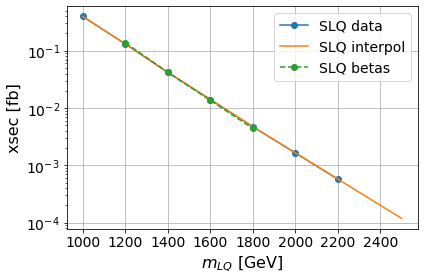

In [17]:
# CHECK

masses_SLQ_betas_14TeV = [1200, 1400, 1600, 1800]
fidxsec_SLQ_beta05_14TeV = [xsec_data_betas_14TeV[3,ii+1] for ii in range(len(masses_SLQ_betas_14TeV))]


# plot
plt.plot(masses_SLQ_14TeV, fidxsec_SLQ_non0_14TeV, 'o-', label='SLQ data')

plt.plot(mass_its_14TeV, xsec_SLQ_its_14TeV, '-', label='SLQ interpol')

plt.plot(masses_SLQ_betas_14TeV, fidxsec_SLQ_beta05_14TeV, 'o--', label='SLQ betas')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### betas ratio

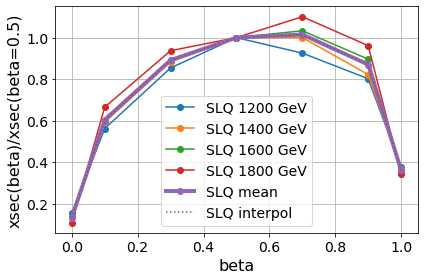

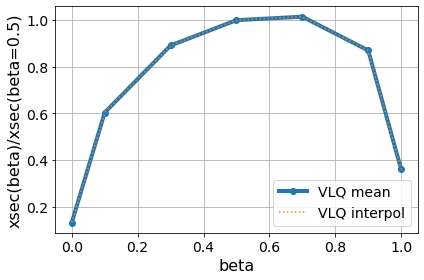

In [18]:
# SLQ
ratio_SLQ1200_14TeV = np.array([fidxsec_SLQ1200_14TeV[b_it]/fidxsec_SLQ1200_14TeV[0.5] for b_it in betas ])
ratio_SLQ1400_14TeV = np.array([fidxsec_SLQ1400_14TeV[b_it]/fidxsec_SLQ1400_14TeV[0.5] for b_it in betas ])
ratio_SLQ1600_14TeV = np.array([fidxsec_SLQ1600_14TeV[b_it]/fidxsec_SLQ1600_14TeV[0.5] for b_it in betas ])
ratio_SLQ1800_14TeV = np.array([fidxsec_SLQ1800_14TeV[b_it]/fidxsec_SLQ1800_14TeV[0.5] for b_it in betas ])

ratio_SLQ_mean_14TeV = np.mean(np.stack([ratio_SLQ1200_14TeV,ratio_SLQ1400_14TeV,ratio_SLQ1600_14TeV,ratio_SLQ1800_14TeV], axis=1), axis=1)

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_SLQ_mean_14TeV, kind='linear', fill_value="extrapolate")
# evaluate
beta_its = np.linspace(0,1,50)
beta_SLQ_its_14TeV = f_ratio_SLQ_log_14TeV(beta_its)


# plot
plt.plot(betas, ratio_SLQ1200_14TeV, 'o-', label='SLQ 1200 GeV')
plt.plot(betas, ratio_SLQ1400_14TeV, 'o-', label='SLQ 1400 GeV')
plt.plot(betas, ratio_SLQ1600_14TeV, 'o-', label='SLQ 1600 GeV')
plt.plot(betas, ratio_SLQ1800_14TeV, 'o-', label='SLQ 1800 GeV')

plt.plot(betas, ratio_SLQ_mean_14TeV, 'o-', lw=4, label='SLQ mean')

plt.plot(beta_its, beta_SLQ_its_14TeV, ':', label='SLQ interpol')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.yscale('log')
plt.xlabel("beta",fontsize=16)
plt.ylabel("xsec(beta)/xsec(beta=0.5)",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()




# VLQ

#  interpolate
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_SLQ_mean_14TeV, kind='linear', fill_value="extrapolate")
# evaluate
beta_VLQ_its_14TeV = f_ratio_VLQ_log_14TeV(beta_its)


# plot
plt.plot(betas, ratio_SLQ_mean_14TeV, 'o-', lw=4, label='VLQ mean')

plt.plot(beta_its, beta_VLQ_its_14TeV, ':', label='VLQ interpol')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.yscale('log')
plt.xlabel("beta",fontsize=16)
plt.ylabel("xsec(beta)/xsec(beta=0.5)",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### final function

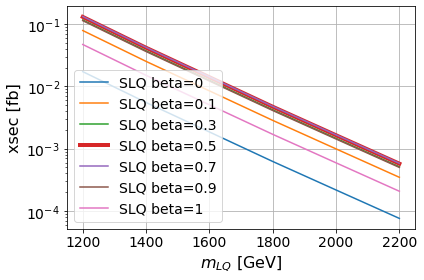

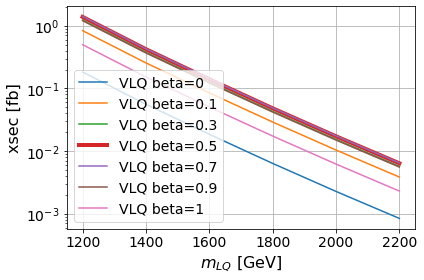

In [19]:
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)


masses_X = np.linspace(1200,2200,100)


# plot SLQ
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0), '-', label='SLQ beta=0')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.1), '-', label='SLQ beta=0.1')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.3), '-', label='SLQ beta=0.3')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.5), '-', lw=4, label='SLQ beta=0.5')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.7), '-', label='SLQ beta=0.7')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.9), '-', label='SLQ beta=0.9')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,1), '-', label='SLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot VLQ
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0), '-', label='VLQ beta=0')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.1), '-', label='VLQ beta=0.1')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.3), '-', label='VLQ beta=0.3')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.5), '-', lw=4, label='VLQ beta=0.5')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.7), '-', label='VLQ beta=0.7')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.9), '-', label='VLQ beta=0.9')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,1), '-', label='VLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# 13.6 TeV

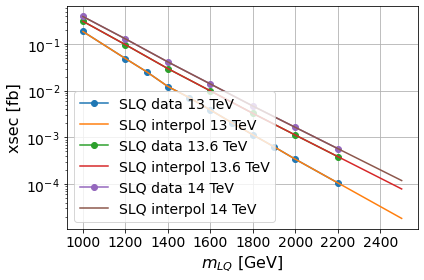

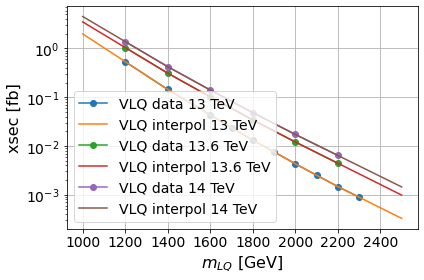

In [20]:
masses_SLQ_136TeV = [1000, 1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_136TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_136TeV = [(fidxsec_SLQ_14TeV[m_it] - fidxsec_SLQ[m_it])*0.6 + fidxsec_SLQ[m_it] for m_it in masses_SLQ_136TeV]
fidxsec_VLQ_136TeV = [(fidxsec_VLQ_14TeV[m_it] - fidxsec_VLQ[m_it])*0.6 + fidxsec_VLQ[m_it] for m_it in masses_VLQ_136TeV]


#  interpolate
f_xsec_SLQ_log_136TeV = interp1d(masses_SLQ_136TeV, np.log10(fidxsec_SLQ_136TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_136TeV = interp1d(masses_VLQ_136TeV, np.log10(fidxsec_VLQ_136TeV), kind='linear', fill_value="extrapolate")

# evaluate
mass_its_136TeV = np.linspace(1000,2500,100)
xsec_SLQ_its_136TeV = 10**f_xsec_SLQ_log_136TeV(mass_its_136TeV)
xsec_VLQ_its_136TeV = 10**f_xsec_VLQ_log_136TeV(mass_its_136TeV)


# plot
plt.plot(masses_SLQ, fidxsec_SLQ_non0, 'o-', label='SLQ data 13 TeV')
plt.plot(mass_its, xsec_SLQ_its, '-', label='SLQ interpol 13 TeV')

plt.plot(masses_SLQ_136TeV, fidxsec_SLQ_136TeV, 'o-', label='SLQ data 13.6 TeV')
plt.plot(mass_its_136TeV, xsec_SLQ_its_136TeV, '-', label='SLQ interpol 13.6 TeV')

plt.plot(masses_SLQ_14TeV, fidxsec_SLQ_non0_14TeV, 'o-', label='SLQ data 14 TeV')
plt.plot(mass_its_14TeV, xsec_SLQ_its_14TeV, '-', label='SLQ interpol 14 TeV')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot
plt.plot(masses_VLQ, fidxsec_VLQ_non0, 'o-', label='VLQ data 13 TeV')
plt.plot(mass_its, xsec_VLQ_its, '-', label='VLQ interpol 13 TeV')

plt.plot(masses_VLQ_136TeV, fidxsec_VLQ_136TeV, 'o-', label='VLQ data 13.6 TeV')
plt.plot(mass_its_136TeV, xsec_VLQ_its_136TeV, '-', label='VLQ interpol 13.6 TeV')

plt.plot(masses_VLQ_14TeV, fidxsec_VLQ_non0_14TeV, 'o-', label='VLQ data 14 TeV')
plt.plot(mass_its_14TeV, xsec_VLQ_its_14TeV, '-', label='VLQ interpol 14 TeV')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### betas

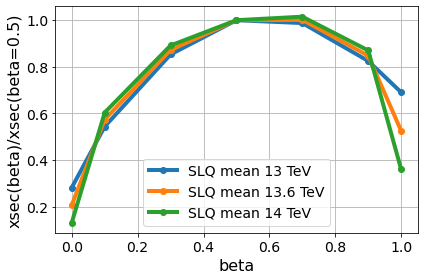

In [22]:
ratio_SLQ_mean_136TeV = [(ratio_SLQ_mean_14TeV[b_it] - ratio_SLQ_mean[b_it])*0.5 + ratio_SLQ_mean[b_it] for b_it in range(len(betas))]


#  interpolate
f_ratio_SLQ_log_136TeV = interp1d(betas, ratio_SLQ_mean_136TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_136TeV = interp1d(betas, ratio_SLQ_mean_136TeV, kind='linear', fill_value="extrapolate")

# evaluate
beta_its = np.linspace(0,1,50)
beta_SLQ_its_136TeV = f_ratio_SLQ_log_136TeV(beta_its)



plt.plot(betas, ratio_SLQ_mean, 'o-', lw=4, label='SLQ mean 13 TeV')
plt.plot(betas, ratio_SLQ_mean_136TeV, 'o-', lw=4, label='SLQ mean 13.6 TeV')
plt.plot(betas, ratio_SLQ_mean_14TeV, 'o-', lw=4, label='SLQ mean 14 TeV')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.yscale('log')
plt.xlabel("beta",fontsize=16)
plt.ylabel("xsec(beta)/xsec(beta=0.5)",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### final function

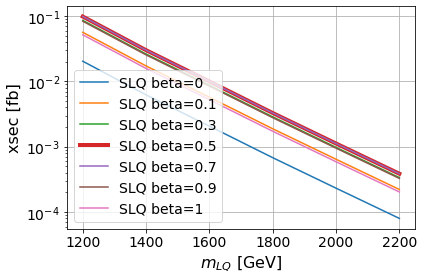

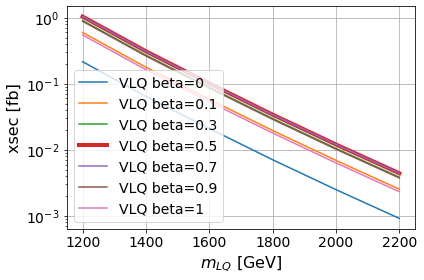

In [23]:
def fid_xsec_SLQ_136TeV(mass, beta):
    return 10**f_xsec_SLQ_log_136TeV(mass) * f_ratio_SLQ_log_136TeV(beta)

def fid_xsec_VLQ_136TeV(mass, beta):
    return 10**f_xsec_VLQ_log_136TeV(mass) * f_ratio_VLQ_log_136TeV(beta)


masses_X = np.linspace(1200,2200,100)


# plot SLQ
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0), '-', label='SLQ beta=0')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.1), '-', label='SLQ beta=0.1')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.3), '-', label='SLQ beta=0.3')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.5), '-', lw=4, label='SLQ beta=0.5')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.7), '-', label='SLQ beta=0.7')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.9), '-', label='SLQ beta=0.9')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,1), '-', label='SLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot VLQ
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0), '-', label='VLQ beta=0')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.1), '-', label='VLQ beta=0.1')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.3), '-', label='VLQ beta=0.3')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.5), '-', lw=4, label='VLQ beta=0.5')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.7), '-', label='VLQ beta=0.7')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.9), '-', label='VLQ beta=0.9')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,1), '-', label='VLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# THIS IS JUST SHORTER

# 13 TeV

In [2]:
# -------------------------
# cross sections
# -------------------------
xsec_file = '../DATA-wjets/signals/LQs-xsec-13TeV.txt'

xsec_data = np.loadtxt(xsec_file, comments='#')


# columns: 0=mass, 1=SLQ, 2=VLQ
masses = xsec_data[:,0].astype(int)
fidxsec_SLQ = dict(zip(masses, xsec_data[:,1]))
fidxsec_VLQ = dict(zip(masses, xsec_data[:,2]))


masses_SLQ = [1000, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
masses_VLQ = [1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

fidxsec_SLQ_non0 = [fidxsec_SLQ[ii] for ii in masses_SLQ]
fidxsec_VLQ_non0 = [fidxsec_VLQ[ii] for ii in masses_VLQ]


#  interpolate
f_xsec_SLQ_log = interp1d(masses_SLQ, np.log10(fidxsec_SLQ_non0), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log = interp1d(masses_VLQ, np.log10(fidxsec_VLQ_non0), kind='linear', fill_value="extrapolate")




# -------------------------
# cross sections
# -------------------------
xsec_file_betas = '../DATA-wjets/signals/LQs-xsec-13TeV-betas.txt'

xsec_data_betas = np.loadtxt(xsec_file_betas, comments='#')

# columns: 0=beta, 1...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas[:,0]
ratio_mean = xsec_data_betas[:,-1]


#  interpolate
f_ratio_SLQ_log = interp1d(betas, ratio_mean, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log = interp1d(betas, ratio_mean, kind='linear', fill_value="extrapolate")



# FINAL FUNCIONS
def fid_xsec_SLQ_13TeV(mass, beta):
    return 10**f_xsec_SLQ_log(mass) * f_ratio_SLQ_log(beta)

def fid_xsec_VLQ_13TeV(mass, beta):
    return 10**f_xsec_VLQ_log(mass) * f_ratio_VLQ_log(beta)

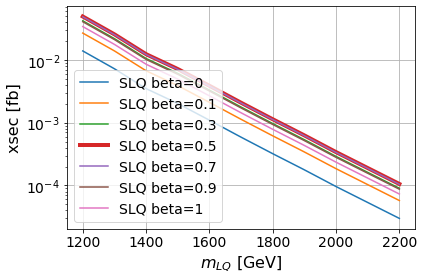

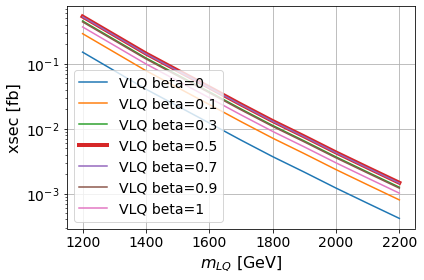

In [3]:

masses_X = np.linspace(1200,2200,100)


# plot SLQ
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0), '-', label='SLQ beta=0')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.1), '-', label='SLQ beta=0.1')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.3), '-', label='SLQ beta=0.3')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.5), '-', lw=4, label='SLQ beta=0.5')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.7), '-', label='SLQ beta=0.7')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,0.9), '-', label='SLQ beta=0.9')
plt.plot(masses_X, fid_xsec_SLQ_13TeV(masses_X,1), '-', label='SLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot VLQ
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0), '-', label='VLQ beta=0')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.1), '-', label='VLQ beta=0.1')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.3), '-', label='VLQ beta=0.3')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.5), '-', lw=4, label='VLQ beta=0.5')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.7), '-', label='VLQ beta=0.7')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,0.9), '-', label='VLQ beta=0.9')
plt.plot(masses_X, fid_xsec_VLQ_13TeV(masses_X,1), '-', label='VLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# 13.6 TeV

In [7]:
# -------------------------
# cross sections
# -------------------------
xsec_file_136TeV = '../DATA-wjets/signals/LQs-xsec-136TeV.txt'

xsec_data_136TeV = np.loadtxt(xsec_file_136TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_136TeV = xsec_data_136TeV[:,0].astype(int)
fidxsec_SLQ_136TeV = xsec_data_136TeV[:,1]
fidxsec_VLQ_136TeV = xsec_data_136TeV[:,2]


#  interpolate
f_xsec_SLQ_log_136TeV = interp1d(masses_136TeV, np.log10(fidxsec_SLQ_136TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_136TeV = interp1d(masses_136TeV, np.log10(fidxsec_VLQ_136TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_136TeV = '../DATA-wjets/signals/LQs-xsec-136TeV-betas.txt'

xsec_data_betas_136TeV = np.loadtxt(xsec_file_betas_136TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_136TeV[:,0]
ratio_mean_136TeV = xsec_data_betas_136TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_136TeV = interp1d(betas, ratio_mean_136TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_136TeV = interp1d(betas, ratio_mean_136TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_136TeV(mass, beta):
    return 10**f_xsec_SLQ_log_136TeV(mass) * f_ratio_SLQ_log_136TeV(beta)

def fid_xsec_VLQ_136TeV(mass, beta):
    return 10**f_xsec_VLQ_log_136TeV(mass) * f_ratio_VLQ_log_136TeV(beta)


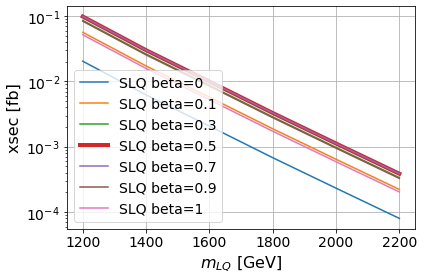

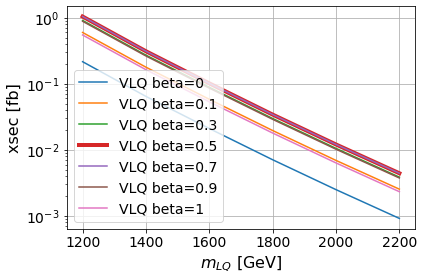

In [11]:


masses_X = np.linspace(1200,2200,100)


# plot SLQ
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0), '-', label='SLQ beta=0')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.1), '-', label='SLQ beta=0.1')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.3), '-', label='SLQ beta=0.3')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.5), '-', lw=4, label='SLQ beta=0.5')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.7), '-', label='SLQ beta=0.7')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,0.9), '-', label='SLQ beta=0.9')
plt.plot(masses_X, fid_xsec_SLQ_136TeV(masses_X,1), '-', label='SLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot VLQ
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0), '-', label='VLQ beta=0')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.1), '-', label='VLQ beta=0.1')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.3), '-', label='VLQ beta=0.3')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.5), '-', lw=4, label='VLQ beta=0.5')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.7), '-', label='VLQ beta=0.7')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,0.9), '-', label='VLQ beta=0.9')
plt.plot(masses_X, fid_xsec_VLQ_136TeV(masses_X,1), '-', label='VLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# 14 TeV

In [4]:
# -------------------------
# cross sections
# -------------------------
xsec_file_14TeV = '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)
fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]))


masses_SLQ_14TeV = [1000, 1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_14TeV[:,0]
ratio_mean_14TeV = xsec_data_betas_14TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)


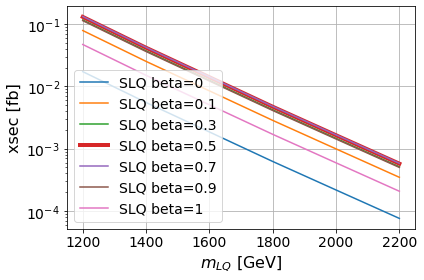

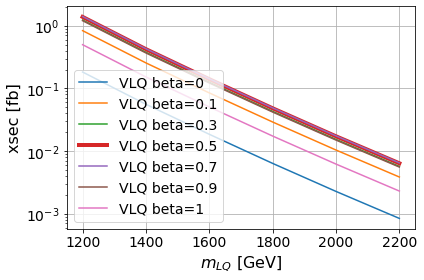

In [5]:


masses_X = np.linspace(1200,2200,100)


# plot SLQ
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0), '-', label='SLQ beta=0')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.1), '-', label='SLQ beta=0.1')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.3), '-', label='SLQ beta=0.3')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.5), '-', lw=4, label='SLQ beta=0.5')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.7), '-', label='SLQ beta=0.7')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,0.9), '-', label='SLQ beta=0.9')
plt.plot(masses_X, fid_xsec_SLQ_14TeV(masses_X,1), '-', label='SLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot VLQ
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0), '-', label='VLQ beta=0')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.1), '-', label='VLQ beta=0.1')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.3), '-', label='VLQ beta=0.3')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.5), '-', lw=4, label='VLQ beta=0.5')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.7), '-', label='VLQ beta=0.7')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,0.9), '-', label='VLQ beta=0.9')
plt.plot(masses_X, fid_xsec_VLQ_14TeV(masses_X,1), '-', label='VLQ beta=1')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel("xsec [fb]",fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()